In [1]:
import json
import re
from pathlib import Path

In [2]:
RESULTS_DIR = Path("results")

def _flag_pattern(value) -> str:
    """Convert a filter value to a regex fragment. '*' matches anything."""
    if value == "*":
        return r".*"
    return re.escape(str(value))


def load_results(
    dataset="*",
    ef_construction="*",
    ef_init="*",
    extend_candidates="*",
    keep_pruned_connections="*",
    use_heuristic="*",
    strict_ef="*",
    threshold_based_neighbourhood="*",
    leiden_objective="*",
) -> list[dict]:
    """
    Load ablation results filtered by any combination of parameters.
    Pass '*' for a parameter to accept any value.

    Boolean parameters accept True, False, or '*'.
    leiden_objective accepts 'modularity', 'cpm', or '*'.
    """

    # --- build a regex that matches the stem ---
    # dataset segment
    ds_pat = _flag_pattern(dataset)

    # numeric segments
    efc_pat = _flag_pattern(ef_construction)
    efi_pat = _flag_pattern(ef_init)

    # optional flag tokens: each is either required present, required absent, or free
    def flag_seg(value, token):
        if value == "*":
            return rf"(?:-{token})?"
        elif value is True:
            return rf"-{token}"
        else:  # False
            return rf"(?!.*-{token}\b)"

    # For negative lookaheads we collect them upfront and prepend
    lookaheads = ""
    flag_parts = ""

    bool_flags = [
        (extend_candidates, "EC"),
        (keep_pruned_connections, "KPC"),
        (use_heuristic, "UH"),
        (strict_ef, "SEF"),
        (threshold_based_neighbourhood, "TBN"),
    ]

    for val, token in bool_flags:
        if val is False:
            lookaheads += rf"(?!.*-{token})"
        elif val is True:
            flag_parts += rf"(?=.*-{token})"
        # '*' → no constraint

    # leiden_objective
    if leiden_objective == "cpm":
        flag_parts += r"(?=.*-CPM)"
    elif leiden_objective == "modularity":
        lookaheads += r"(?!.*-CPM)"
    # '*' → no constraint

    pattern = re.compile(
        rf"^{lookaheads}{flag_parts}{ds_pat}_{efc_pat}_{efi_pat}(?:-[A-Z]+)*$"
    )

    results = []
    for path in sorted(RESULTS_DIR.glob("*.json")):
        if pattern.match(path.stem):
            results.append(json.loads(path.read_text()))

    return results


# ef-construction

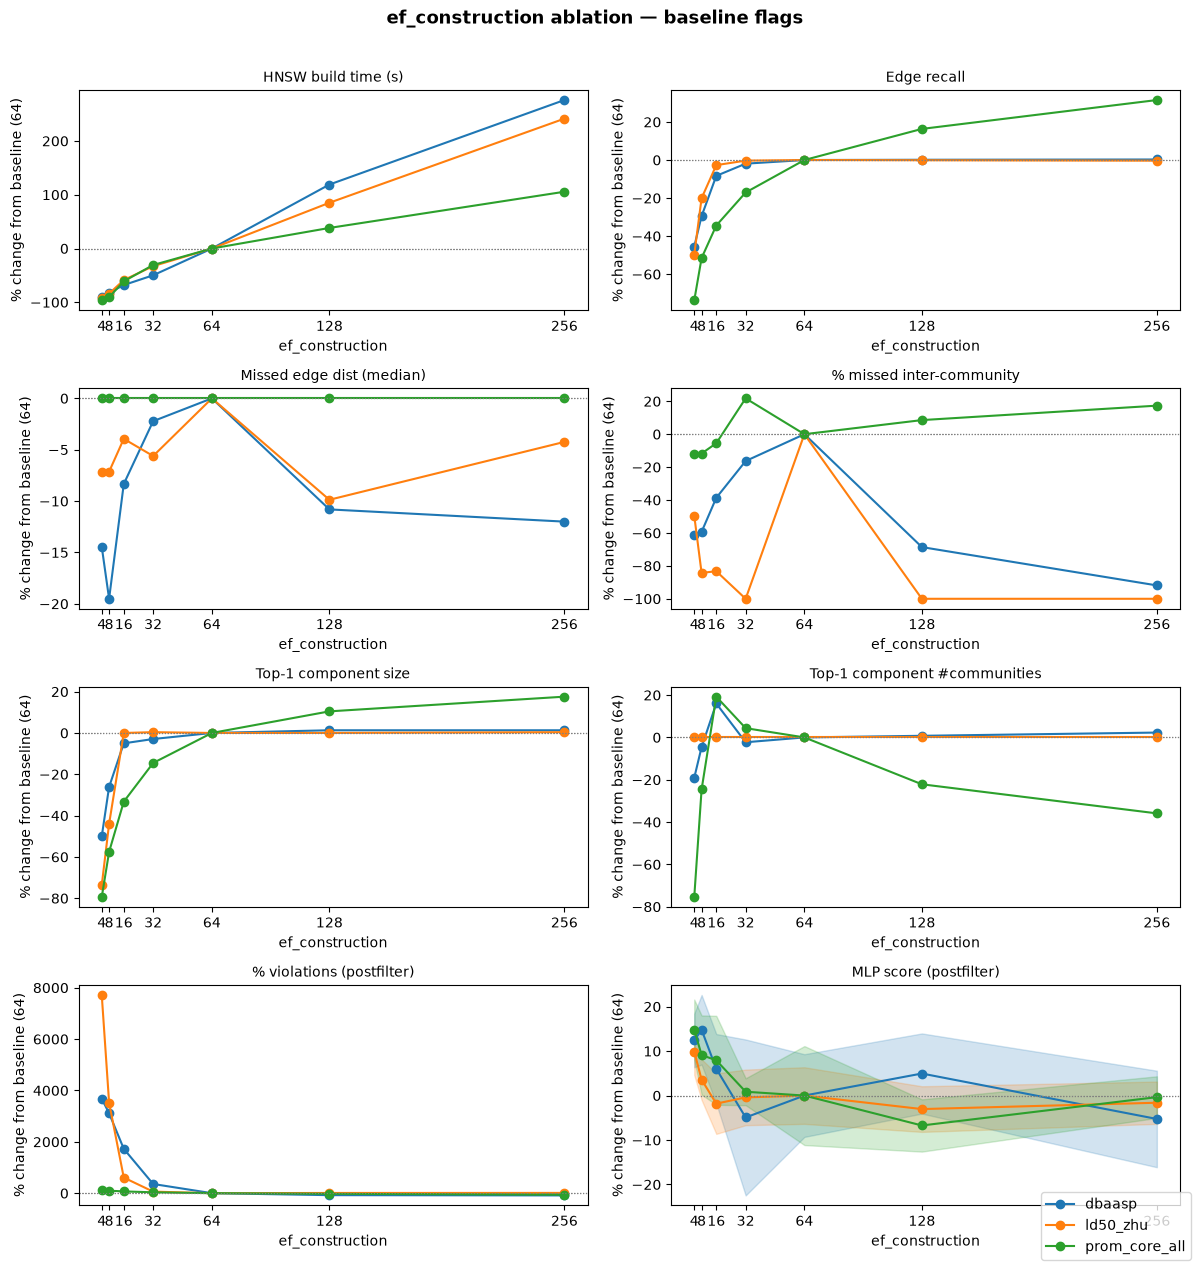

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

BASELINE = dict(
    ef_init=1,
    keep_pruned_connections=True,
    use_heuristic=True,
    leiden_objective="cpm",
    extend_candidates=False,
    strict_ef=False,
    threshold_based_neighbourhood=False,
)

DATASETS = [
    ("dbaasp",        "#1f77b4", "dbaasp"),
    ("ld50_zhu",      "#ff7f0e", "ld50_zhu"),
    ("prom_core_all", "#2ca02c", "prom_core_all"),
]

# MCC datasets use a right y-axis wherever raw MLP scores are shown
DATASET_METRIC = {"dbaasp": "PCC", "ld50_zhu": "PCC", "prom_core_all": "MCC"}

def _get(r, *keys):
    d = r
    for k in keys:
        d = d[k]
    return d

METRICS = [
    ("HNSW build time (s)",          lambda r: (_get(r, "results", "edges", "hnsw_build_time_s"), None)),
    ("Edge recall",                   lambda r: (_get(r, "results", "edges", "pct_edges_recovered"), None)),
    ("Missed edge dist (median)",     lambda r: (_get(r, "results", "edges", "missed_edge_weight_dist", "median"), None)),
    ("% missed inter-community",      lambda r: (_get(r, "results", "edges", "pct_missed_inter_community") * 100, None)),
    ("Top-1 component size",          lambda r: (_get(r, "results", "edges", "top3_components")[0]["size"], None)),
    ("Top-1 component #communities",  lambda r: (_get(r, "results", "edges", "top3_components")[0]["n_communities"], None)),
    ("% violations (postfilter)",     lambda r: (_get(r, "results", "edges", "split", "postfilter", "p_violations_mean[%]"), None)),
    ("MLP score (postfilter)",        lambda r: (
        _get(r, "results", "edges", "split", "postfilter", "mlp_score_mean"),
        _get(r, "results", "edges", "split", "postfilter", "mlp_score_std"),
    )),
]

MLP_METRIC_IDX = len(METRICS) - 1

EFC_BASELINE = 64

ncols = 2
nrows = (len(METRICS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.2))
axes = axes.flatten()

for ds_key, color, label in DATASETS:
    runs = load_results(dataset=ds_key, **BASELINE)
    runs.sort(key=lambda r: r["input"]["ef_construction"])
    xs = [r["input"]["ef_construction"] for r in runs]

    baseline_run = next(r for r in runs if r["input"]["ef_construction"] == EFC_BASELINE)

    for ax, (title, fn) in zip(axes, METRICS):
        vals = [fn(r) for r in runs]
        ys_raw  = np.array([v[0] for v in vals], dtype=float)
        std_raw = np.array([v[1] if v[1] is not None else np.nan for v in vals], dtype=float)

        y0 = fn(baseline_run)[0]
        ys  = (ys_raw  - y0) / abs(y0) * 100
        std = std_raw / abs(y0) * 100

        ax.plot(xs, ys, marker="o", color=color, label=label)
        if not np.all(np.isnan(std)):
            ax.fill_between(xs, ys - std, ys + std, color=color, alpha=0.2)
        ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("ef_construction")
        ax.set_ylabel("% change from baseline (64)")
        ax.xaxis.set_major_locator(mticker.FixedLocator(xs))

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=10)
fig.suptitle("ef_construction ablation — baseline flags", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


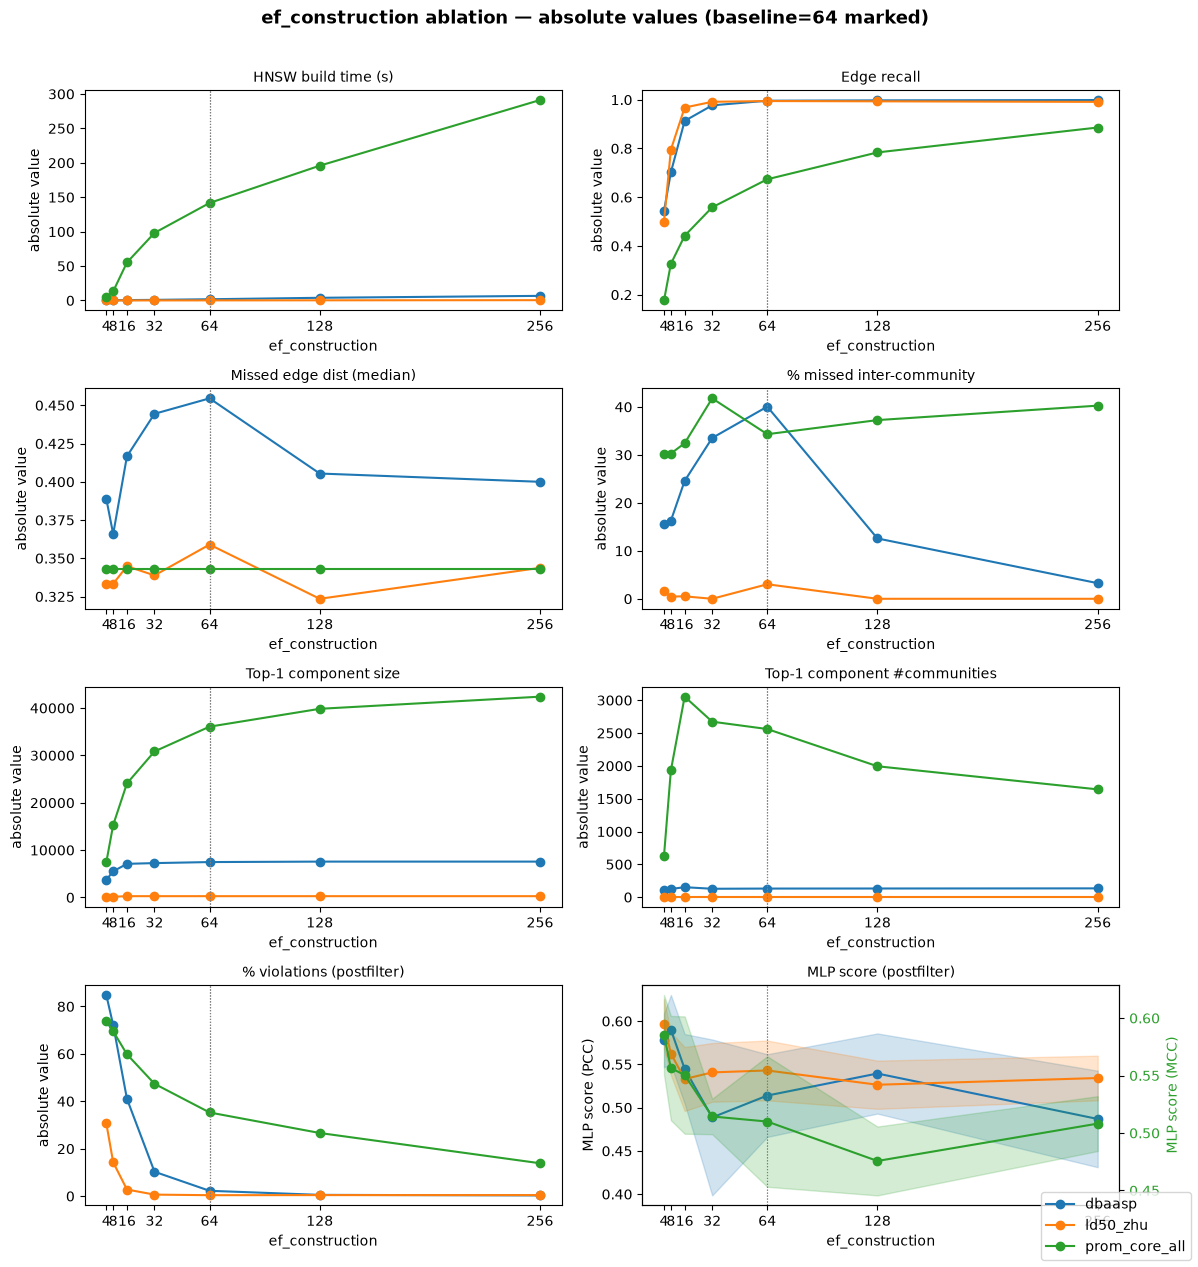

In [4]:
ncols = 2
nrows = (len(METRICS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.2))
axes = axes.flatten()

twin_axes = {}  # ax -> twinx, created on demand for MLP score panel

for ds_key, color, label in DATASETS:
    runs = load_results(dataset=ds_key, **BASELINE)
    runs.sort(key=lambda r: r["input"]["ef_construction"])
    xs = [r["input"]["ef_construction"] for r in runs]
    is_mcc = DATASET_METRIC[ds_key] == "MCC"

    for ax_idx, (ax, (title, fn)) in enumerate(zip(axes, METRICS)):
        vals = [fn(r) for r in runs]
        ys  = np.array([v[0] for v in vals], dtype=float)
        std = np.array([v[1] if v[1] is not None else np.nan for v in vals], dtype=float)

        if ax_idx == MLP_METRIC_IDX and is_mcc:
            if ax not in twin_axes:
                twin_axes[ax] = ax.twinx()
                twin_axes[ax].set_ylabel("MLP score (MCC)", color="#2ca02c")
                twin_axes[ax].tick_params(axis="y", labelcolor="#2ca02c")
            target = twin_axes[ax]
        else:
            target = ax

        target.plot(xs, ys, marker="o", color=color, label=label)
        if not np.all(np.isnan(std)):
            target.fill_between(xs, ys - std, ys + std, color=color, alpha=0.2)

        if ax_idx != MLP_METRIC_IDX or not is_mcc:
            ax.axvline(EFC_BASELINE, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("ef_construction")
        if ax_idx == MLP_METRIC_IDX:
            ax.set_ylabel("MLP score (PCC)")
        else:
            ax.set_ylabel("absolute value")
        ax.xaxis.set_major_locator(mticker.FixedLocator(xs))

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

handles, labels_h = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_h, loc="lower right", fontsize=10)
fig.suptitle("ef_construction ablation — absolute values (baseline=64 marked)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


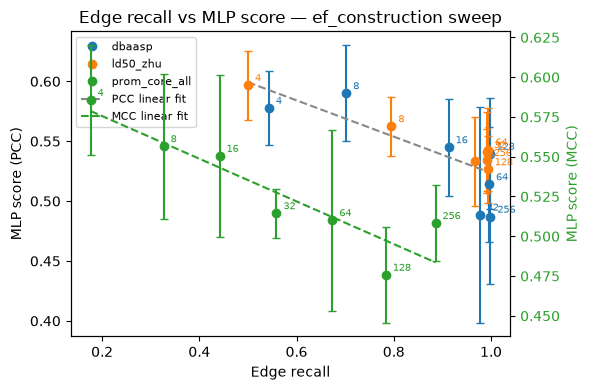

In [5]:
from matplotlib.lines import Line2D
from scipy import stats

fig, ax = plt.subplots(figsize=(6, 4))
ax2 = ax.twinx()
ax2.set_ylabel("MLP score (MCC)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

pcc_recalls, pcc_scores = [], []
mcc_recalls, mcc_scores = [], []

for ds_key, color, label in DATASETS:
    runs = load_results(dataset=ds_key, **BASELINE)
    is_mcc = DATASET_METRIC[ds_key] == "MCC"
    target = ax2 if is_mcc else ax
    for r in runs:
        recall = _get(r, "results", "edges", "pct_edges_recovered")
        score  = _get(r, "results", "edges", "split", "postfilter", "mlp_score_mean")
        std    = _get(r, "results", "edges", "split", "postfilter", "mlp_score_std")
        target.errorbar(recall, score, yerr=std, fmt="o", color=color, capsize=3)
        target.annotate(str(r["input"]["ef_construction"]), (recall, score),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, color=color)
        if is_mcc:
            mcc_recalls.append(recall); mcc_scores.append(score)
        else:
            pcc_recalls.append(recall); pcc_scores.append(score)

for recalls, scores, axis, color, lbl in [
    (pcc_recalls, pcc_scores, ax,  "#888888", "PCC fit"),
    (mcc_recalls, mcc_scores, ax2, "#2ca02c", "MCC fit"),
]:
    if len(recalls) >= 2:
        slope, intercept, r_val, p_val, _ = stats.linregress(recalls, scores)
        x_fit = np.linspace(min(recalls), max(recalls), 100)
        axis.plot(x_fit, slope * x_fit + intercept, color=color, linestyle="--", linewidth=1.5,
                  label=f"{lbl}  r={r_val:.2f}, p={p_val:.3g}")

legend_handles = [Line2D([0], [0], marker="o", color=c, linestyle="none", label=l)
                  for _, c, l in DATASETS]
legend_handles += [Line2D([0], [0], color="#888888", linestyle="--", label=f"PCC linear fit")]
legend_handles += [Line2D([0], [0], color="#2ca02c", linestyle="--", label=f"MCC linear fit")]
ax.legend(handles=legend_handles, fontsize=8)
ax.set_xlabel("Edge recall")
ax.set_ylabel("MLP score (PCC)")
ax.set_title("Edge recall vs MLP score — ef_construction sweep")
plt.tight_layout()
plt.show()


# ef-init

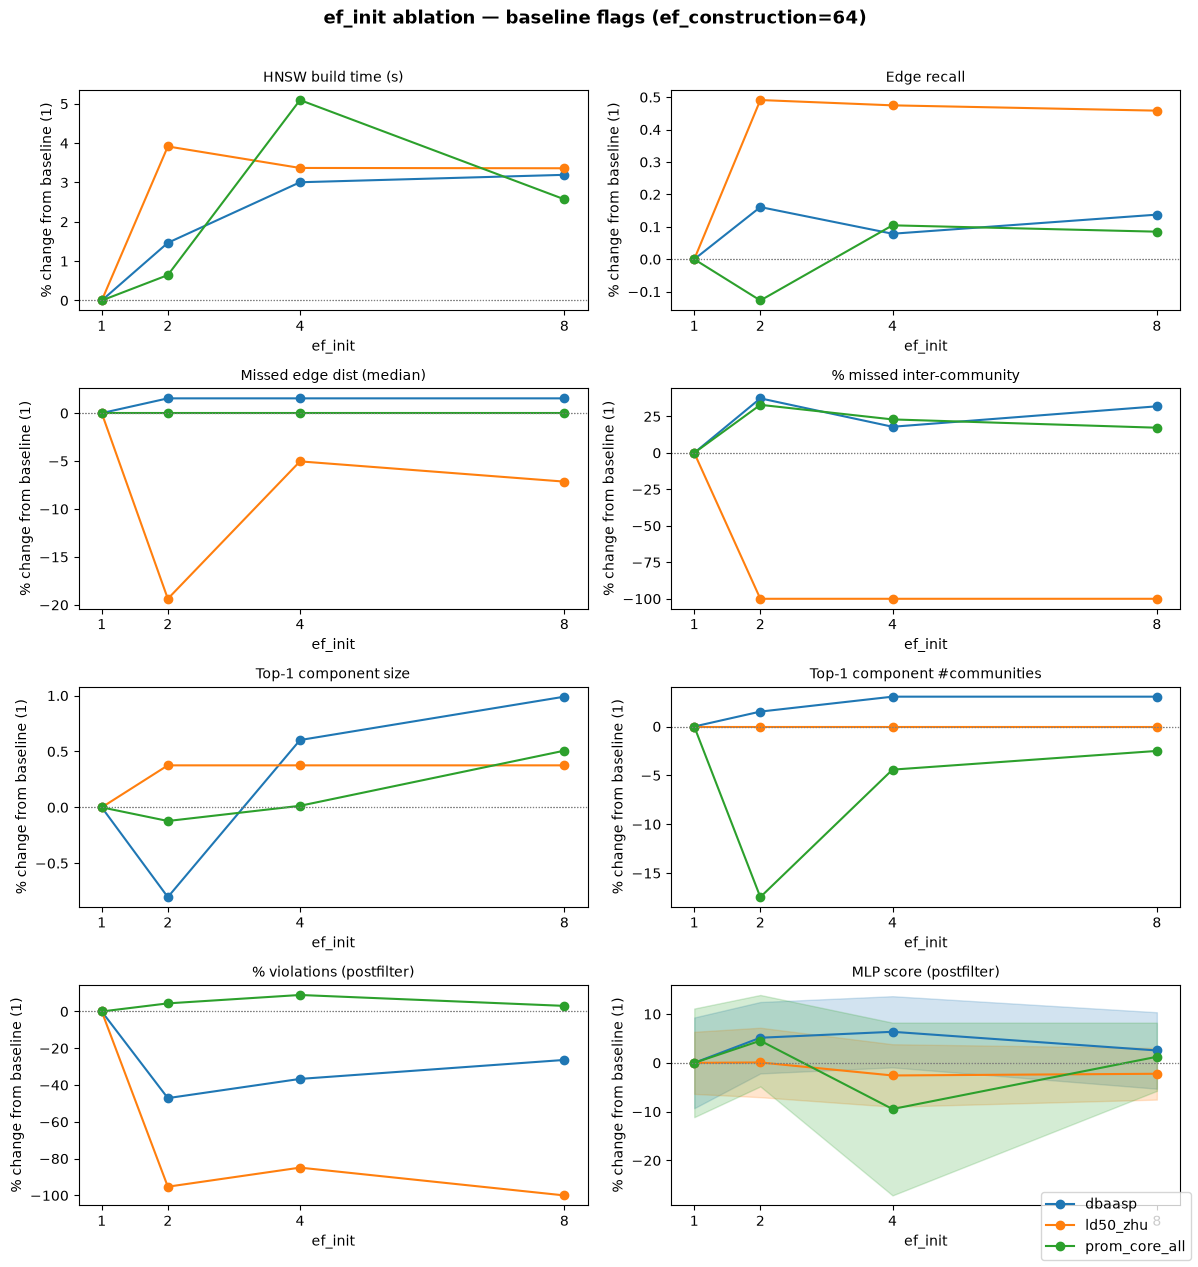

In [6]:
EF_INIT_BASELINE_VAL = 1

EF_INIT_BASELINE = dict(
    ef_construction=64,
    keep_pruned_connections=True,
    use_heuristic=True,
    leiden_objective="cpm",
    extend_candidates=False,
    strict_ef=False,
    threshold_based_neighbourhood=False,
)

ncols = 2
nrows = (len(METRICS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.2))
axes = axes.flatten()

for ds_key, color, label in DATASETS:
    runs = load_results(dataset=ds_key, **EF_INIT_BASELINE)
    runs.sort(key=lambda r: r["input"]["ef_init"])
    xs = [r["input"]["ef_init"] for r in runs]

    baseline_run = next(r for r in runs if r["input"]["ef_init"] == EF_INIT_BASELINE_VAL)

    for ax, (title, fn) in zip(axes, METRICS):
        vals = [fn(r) for r in runs]
        ys_raw  = np.array([v[0] for v in vals], dtype=float)
        std_raw = np.array([v[1] if v[1] is not None else np.nan for v in vals], dtype=float)

        y0 = fn(baseline_run)[0]
        ys  = (ys_raw  - y0) / abs(y0) * 100
        std = std_raw / abs(y0) * 100

        ax.plot(xs, ys, marker="o", color=color, label=label)
        if not np.all(np.isnan(std)):
            ax.fill_between(xs, ys - std, ys + std, color=color, alpha=0.2)
        ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("ef_init")
        ax.set_ylabel("% change from baseline (1)")
        ax.xaxis.set_major_locator(mticker.FixedLocator(xs))

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", fontsize=10)
fig.suptitle("ef_init ablation — baseline flags (ef_construction=64)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


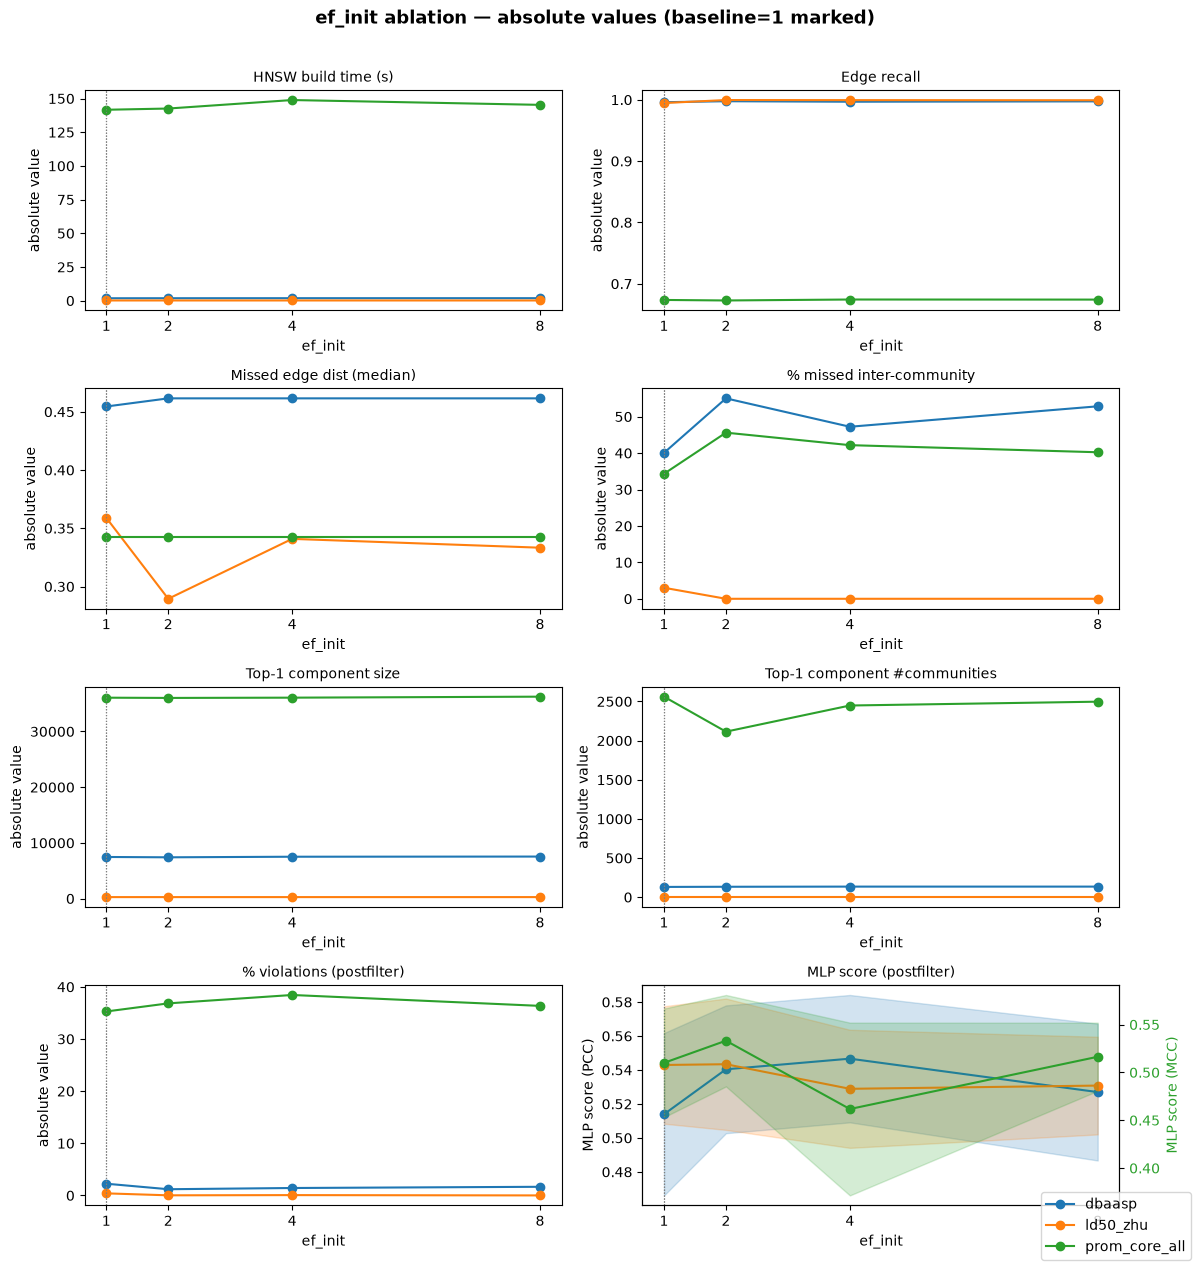

In [7]:
ncols = 2
nrows = (len(METRICS) + 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.2))
axes = axes.flatten()

twin_axes = {}  # ax -> twinx, created on demand for MLP score panel

for ds_key, color, label in DATASETS:
    runs = load_results(dataset=ds_key, **EF_INIT_BASELINE)
    runs.sort(key=lambda r: r["input"]["ef_init"])
    xs = [r["input"]["ef_init"] for r in runs]
    is_mcc = DATASET_METRIC[ds_key] == "MCC"

    for ax_idx, (ax, (title, fn)) in enumerate(zip(axes, METRICS)):
        vals = [fn(r) for r in runs]
        ys  = np.array([v[0] for v in vals], dtype=float)
        std = np.array([v[1] if v[1] is not None else np.nan for v in vals], dtype=float)

        if ax_idx == MLP_METRIC_IDX and is_mcc:
            if ax not in twin_axes:
                twin_axes[ax] = ax.twinx()
                twin_axes[ax].set_ylabel("MLP score (MCC)", color="#2ca02c")
                twin_axes[ax].tick_params(axis="y", labelcolor="#2ca02c")
            target = twin_axes[ax]
        else:
            target = ax

        target.plot(xs, ys, marker="o", color=color, label=label)
        if not np.all(np.isnan(std)):
            target.fill_between(xs, ys - std, ys + std, color=color, alpha=0.2)

        ax.axvline(EF_INIT_BASELINE_VAL, color="gray", linestyle=":", linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.set_xlabel("ef_init")
        if ax_idx == MLP_METRIC_IDX:
            ax.set_ylabel("MLP score (PCC)")
        else:
            ax.set_ylabel("absolute value")
        ax.xaxis.set_major_locator(mticker.FixedLocator(xs))

for ax in axes[len(METRICS):]:
    ax.set_visible(False)

handles, labels_h = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_h, loc="lower right", fontsize=10)
fig.suptitle("ef_init ablation — absolute values (baseline=1 marked)", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


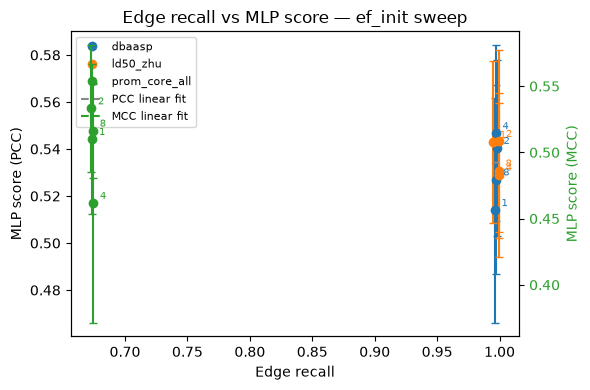

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax2 = ax.twinx()
ax2.set_ylabel("MLP score (MCC)", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

pcc_recalls, pcc_scores = [], []
mcc_recalls, mcc_scores = [], []

for ds_key, color, label in DATASETS:
    runs = load_results(dataset=ds_key, **EF_INIT_BASELINE)
    is_mcc = DATASET_METRIC[ds_key] == "MCC"
    target = ax2 if is_mcc else ax
    for r in runs:
        recall = _get(r, "results", "edges", "pct_edges_recovered")
        score  = _get(r, "results", "edges", "split", "postfilter", "mlp_score_mean")
        std    = _get(r, "results", "edges", "split", "postfilter", "mlp_score_std")
        target.errorbar(recall, score, yerr=std, fmt="o", color=color, capsize=3)
        target.annotate(str(r["input"]["ef_init"]), (recall, score),
                        textcoords="offset points", xytext=(5, 3), fontsize=7, color=color)
        if is_mcc:
            mcc_recalls.append(recall); mcc_scores.append(score)
        else:
            pcc_recalls.append(recall); pcc_scores.append(score)

for recalls, scores, axis, color, lbl in [
    (pcc_recalls, pcc_scores, ax,  "#888888", "PCC fit"),
    (mcc_recalls, mcc_scores, ax2, "#2ca02c", "MCC fit"),
]:
    if len(recalls) >= 2:
        slope, intercept, r_val, p_val, _ = stats.linregress(recalls, scores)
        x_fit = np.linspace(min(recalls), max(recalls), 100)
        axis.plot(x_fit, slope * x_fit + intercept, color=color, linestyle="--", linewidth=1.5,
                  label=f"{lbl}  r={r_val:.2f}, p={p_val:.3g}")

legend_handles = [Line2D([0], [0], marker="o", color=c, linestyle="none", label=l)
                  for _, c, l in DATASETS]
legend_handles += [Line2D([0], [0], color="#888888", linestyle="--", label="PCC linear fit")]
legend_handles += [Line2D([0], [0], color="#2ca02c", linestyle="--", label="MCC linear fit")]
ax.legend(handles=legend_handles, fontsize=8)
ax.set_xlabel("Edge recall")
ax.set_ylabel("MLP score (PCC)")
ax.set_title("Edge recall vs MLP score — ef_init sweep")
plt.tight_layout()
plt.show()


# Binary flag ablation

In [9]:

FLAG_BASELINE = dict(ef_construction=64, ef_init=1, leiden_objective="cpm",
                     keep_pruned_connections=True, use_heuristic=True,
                     extend_candidates=False, strict_ef=False, threshold_based_neighbourhood=False)

# Each entry: (display label, turned on/off, override kwargs)
FLAG_VARIANTS = [
    ("-keep-pruned-connections",       False, dict(keep_pruned_connections=False)),
    ("-use-heuristic",                 False, dict(use_heuristic=False)),
    ("+extend-candidates",             True,  dict(extend_candidates=True)),
    ("+strict-ef",                     True,  dict(strict_ef=True)),
    ("+threshold-based-neighbourhood", True,  dict(threshold_based_neighbourhood=True)),
]

METRIC_LABELS = [title for title, _ in METRICS]

# True  → higher delta is better (green), negative delta is worse (red)
# False → lower  delta is better (green), positive delta is worse (red)
METRIC_HIGHER_IS_BETTER = [
    False,  # HNSW build time (s)
    True,   # Edge recall
    True,   # Missed edge dist (median)
    True,   # % missed inter-community
    False,  # Top-1 component size
    False,  # Top-1 component #communities
    False,  # % violations (postfilter)
    False,  # MLP score (postfilter)
]

def load_flag_variant(ds_key, overrides):
    kw = {**FLAG_BASELINE, **overrides}
    runs = load_results(dataset=ds_key, **kw)
    return runs[0] if runs else None

def load_flag_baseline(ds_key):
    runs = load_results(dataset=ds_key, **FLAG_BASELINE)
    return runs[0] if runs else None

def pct_delta(run, baseline):
    row = []
    for _, fn in METRICS:
        v, _ = fn(run)
        v0, _ = fn(baseline)
        row.append((v - v0) / abs(v0) * 100 if v0 != 0 else 0.0)
    return row

def delta_color(delta, higher_is_better):
    """Return green if the delta is an improvement, red if a regression."""
    if abs(delta) < 1e-9:
        return "black"
    good = delta > 0 if higher_is_better else delta < 0
    return "#2ca02c" if good else "#d62728"


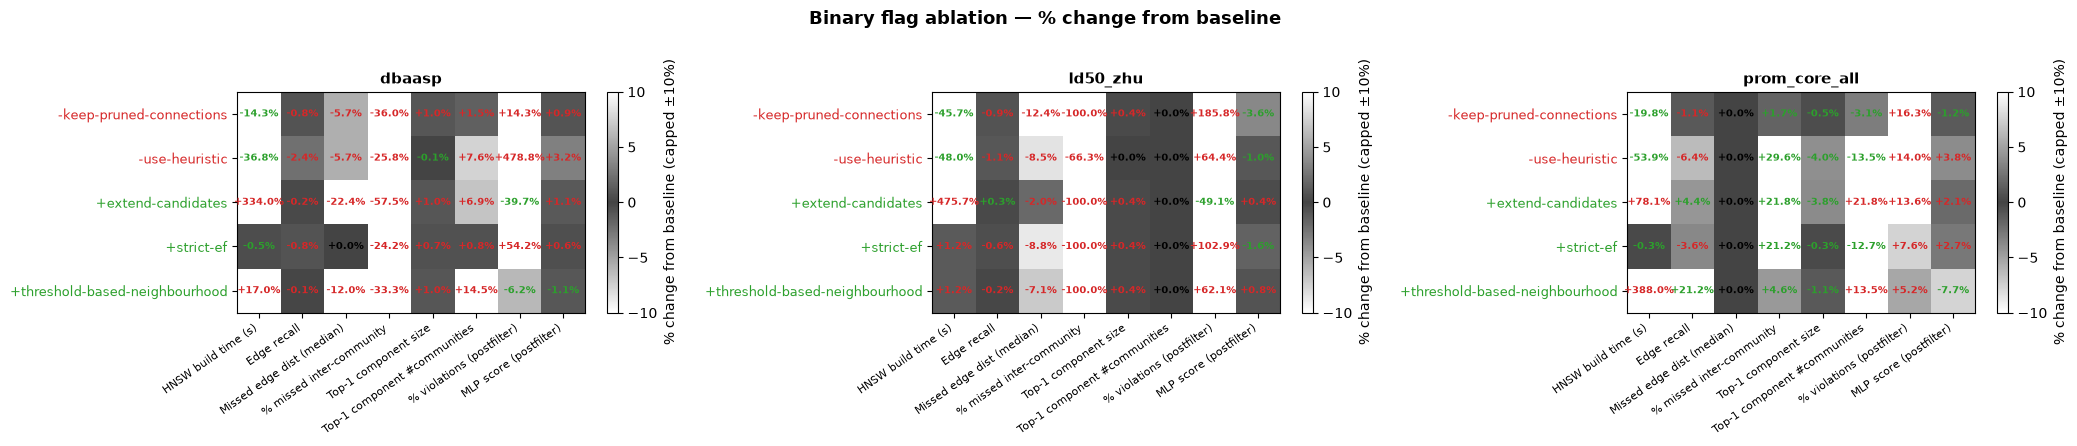

In [10]:

# ── Heatmap ───────────────────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

# Dark at 0 (no change), light at extremes — capped at ±50% so outliers don't wash out
HEATMAP_CAP = 10
cmap_dark_center = LinearSegmentedColormap.from_list("dark_center", ["white", "#444444", "white"])

fig, axes = plt.subplots(1, len(DATASETS), figsize=(7 * len(DATASETS), 4.5), squeeze=False)

for ax, (ds_key, _, ds_label) in zip(axes[0], DATASETS):
    baseline = load_flag_baseline(ds_key)
    if baseline is None:
        ax.set_title(f"{ds_label}\n(no baseline found)")
        continue

    matrix, flag_labels, flag_on = [], [], []
    for label, turned_on, overrides in FLAG_VARIANTS:
        run = load_flag_variant(ds_key, overrides)
        if run is None:
            continue
        matrix.append(pct_delta(run, baseline))
        flag_labels.append(label)
        flag_on.append(turned_on)

    data = np.array(matrix)   # (n_flags, n_metrics)
    data_capped = np.clip(data, -HEATMAP_CAP, HEATMAP_CAP)

    im = ax.imshow(data_capped, aspect="auto", cmap=cmap_dark_center,
                   vmin=-HEATMAP_CAP, vmax=HEATMAP_CAP)
    plt.colorbar(im, ax=ax, label=f"% change from baseline (capped ±{HEATMAP_CAP}%)")

    ax.set_xticks(range(len(METRIC_LABELS)))
    ax.set_xticklabels(METRIC_LABELS, rotation=35, ha="right", fontsize=8)
    ax.set_yticks(range(len(flag_labels)))

    # y-tick label color: green for +flag, red for -flag
    ax.set_yticklabels(flag_labels, fontsize=9)
    for tick, turned_on in zip(ax.get_yticklabels(), flag_on):
        tick.set_color("#2ca02c" if turned_on else "#d62728")

    # annotate cells with true (uncapped) value; text color = green/red by quality
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            color = delta_color(data[i, j], METRIC_HIGHER_IS_BETTER[j])
            ax.text(j, i, f"{data[i, j]:+.1f}%", ha="center", va="center",
                    fontsize=7, fontweight="bold", color=color)

    ax.set_title(f"{ds_label}", fontsize=11, fontweight="bold")

fig.suptitle("Binary flag ablation — % change from baseline", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


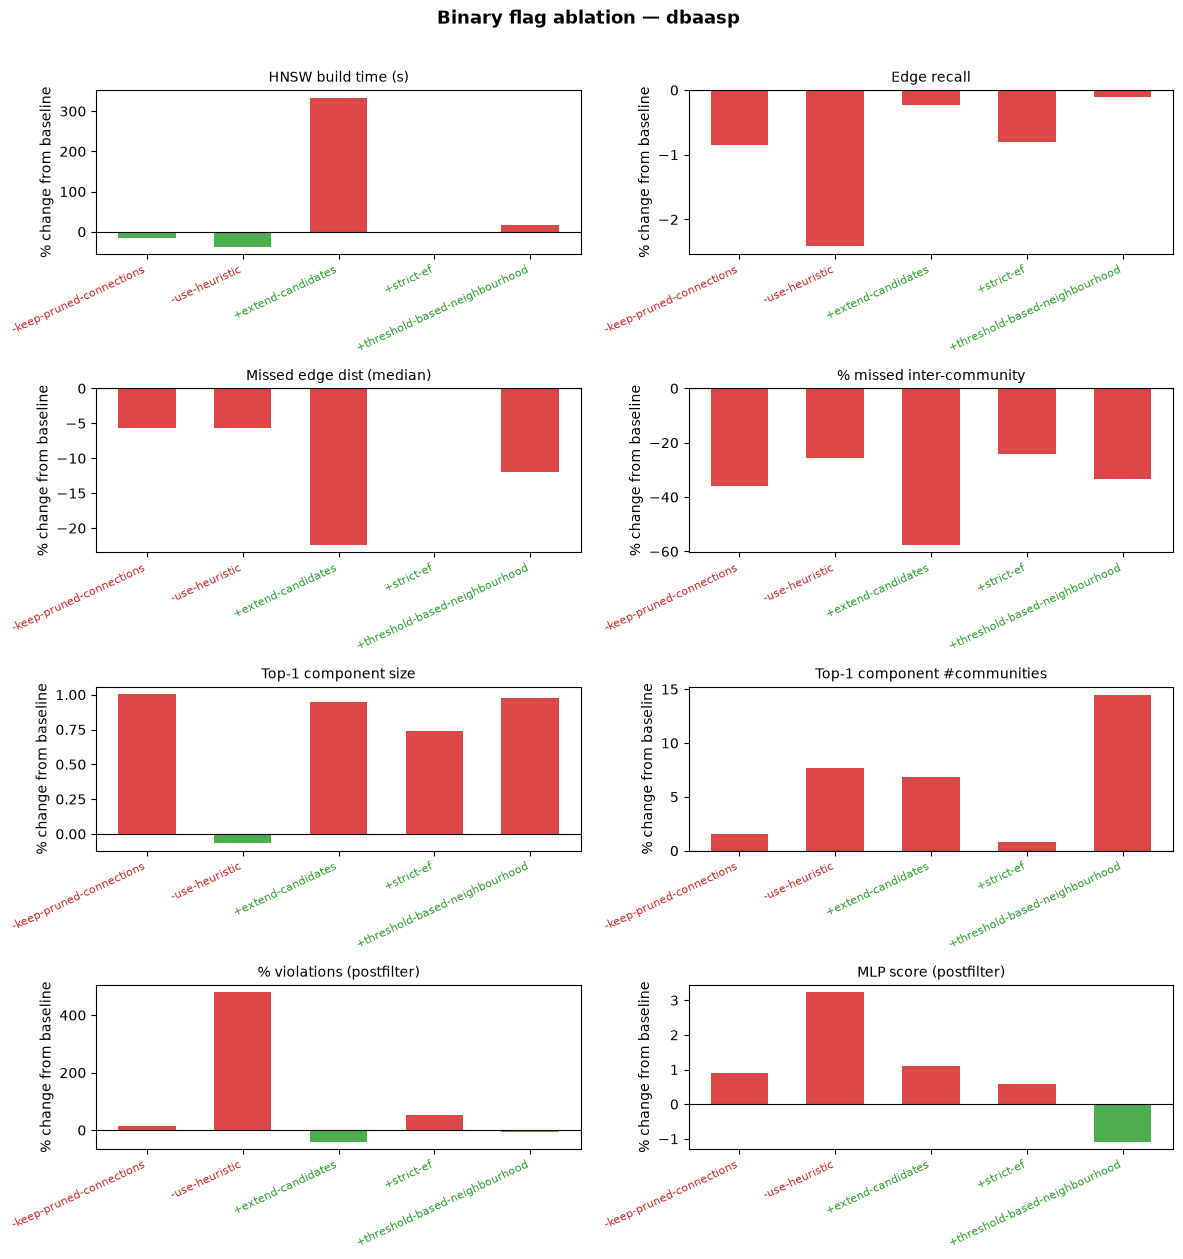

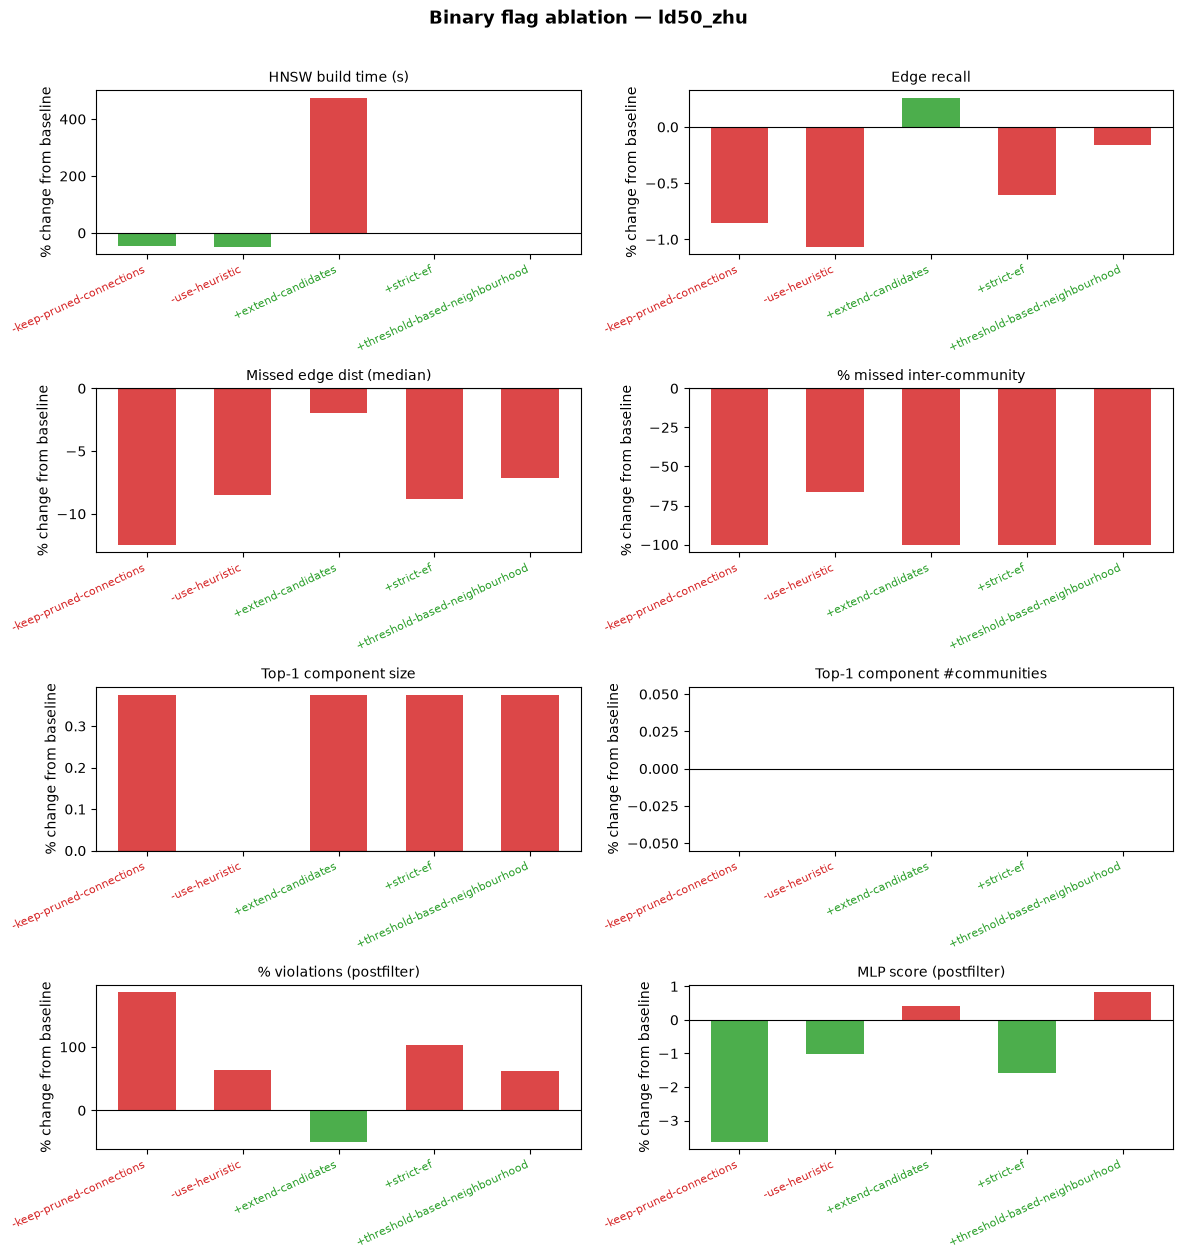

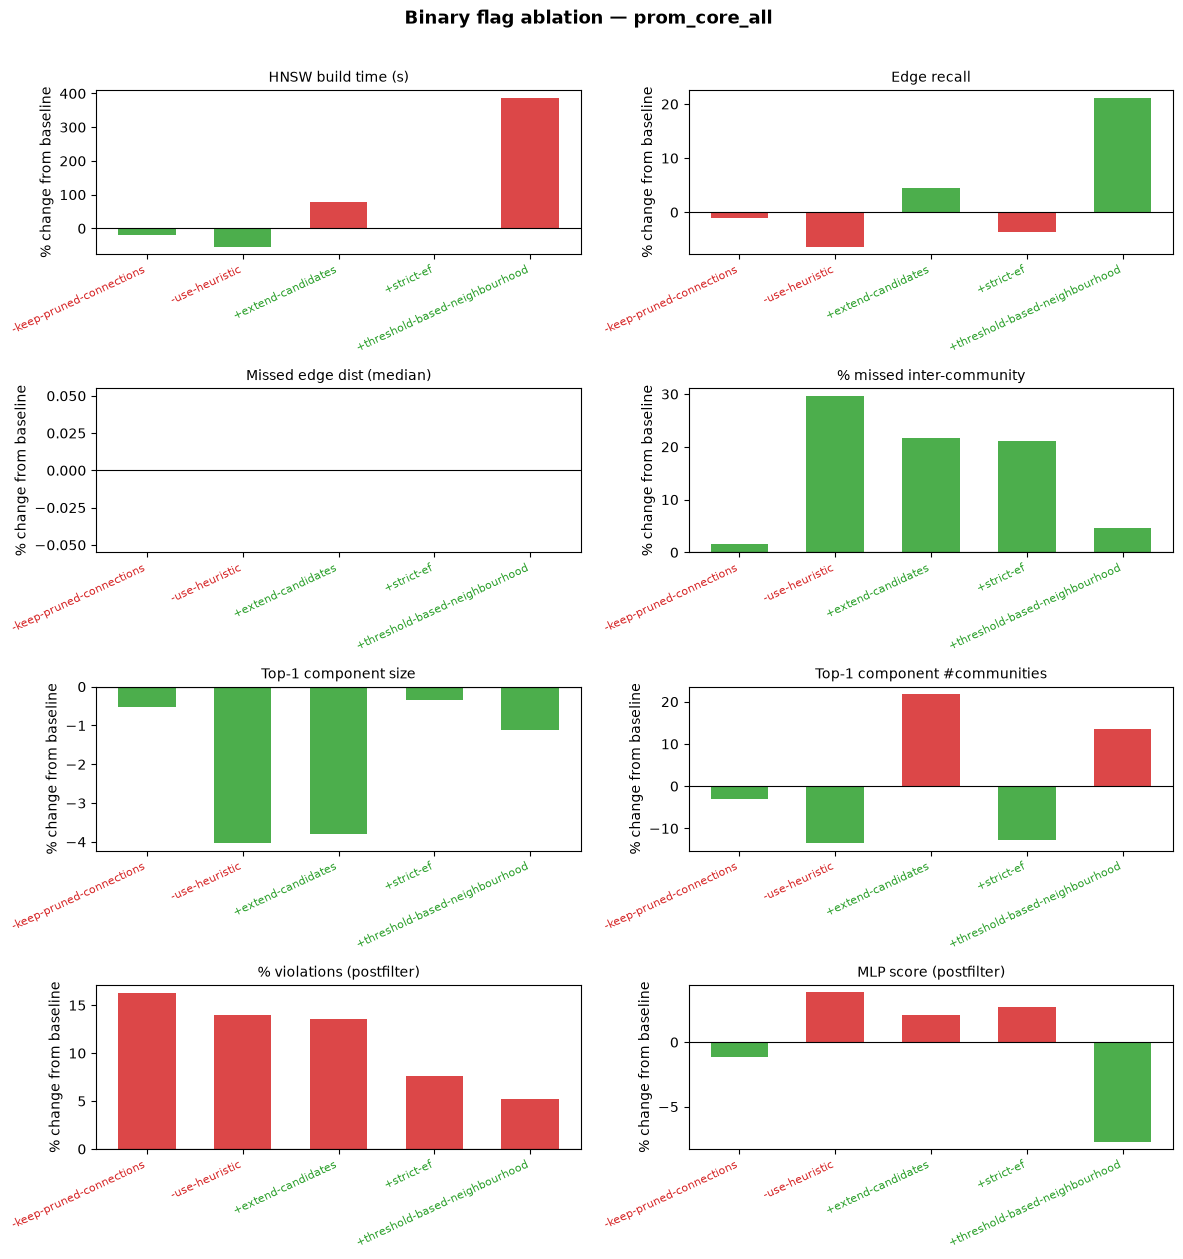

In [11]:

# ── Grouped bar chart — one figure per dataset, x = flag variants ─────────────
x = np.arange(len(FLAG_VARIANTS))
xtick_labels = [lbl for lbl, _, _ in FLAG_VARIANTS]
xtick_colors = ["#2ca02c" if on else "#d62728" for _, on, _ in FLAG_VARIANTS]

ncols = 2
nrows = (len(METRICS) + 1) // ncols

for ds_key, ds_color, ds_label in DATASETS:
    baseline = load_flag_baseline(ds_key)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.2))
    axes = axes.flatten()

    for metric_idx, (title, fn) in enumerate(METRICS):
        ax = axes[metric_idx]
        higher_is_better = METRIC_HIGHER_IS_BETTER[metric_idx]

        deltas, bar_colors = [], []
        for label, turned_on, overrides in FLAG_VARIANTS:
            run = load_flag_variant(ds_key, overrides)
            d = 0.0 if (baseline is None or run is None) else pct_delta(run, baseline)[metric_idx]
            deltas.append(d)
            bar_colors.append(delta_color(d, higher_is_better))

        ax.bar(x, deltas, color=bar_colors, alpha=0.85, width=0.6)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(title, fontsize=10)
        ax.set_ylabel("% change from baseline")
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, fontsize=8, rotation=25, ha="right")
        for tick, color in zip(ax.get_xticklabels(), xtick_colors):
            tick.set_color(color)

    for ax in axes[len(METRICS):]:
        ax.set_visible(False)

    fig.suptitle(f"Binary flag ablation — {ds_label}", fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


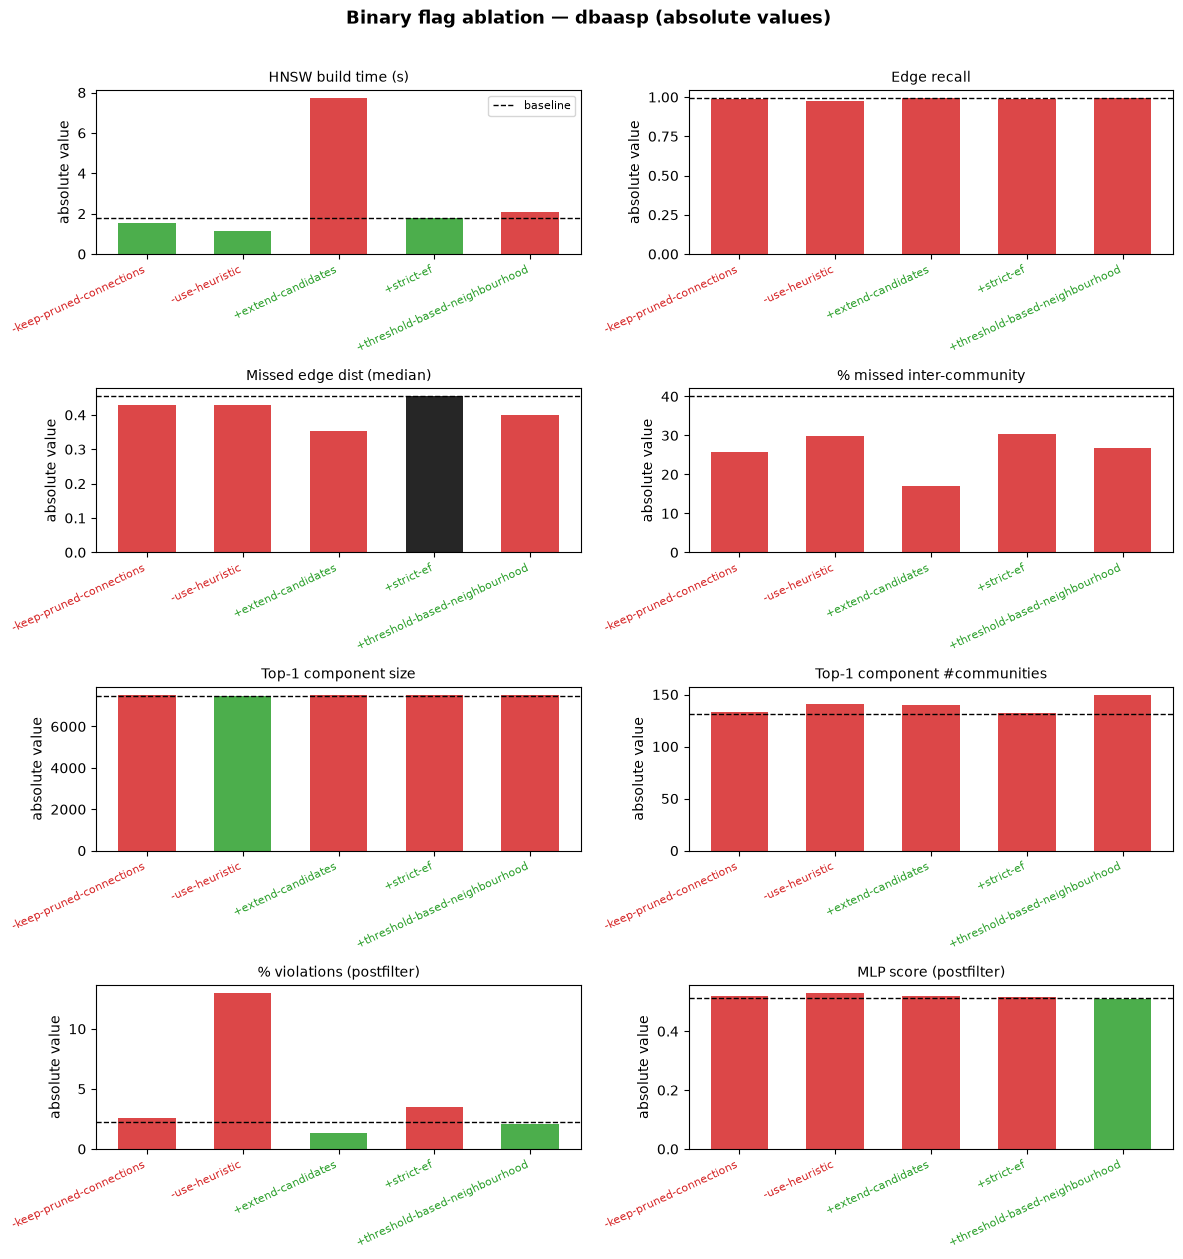

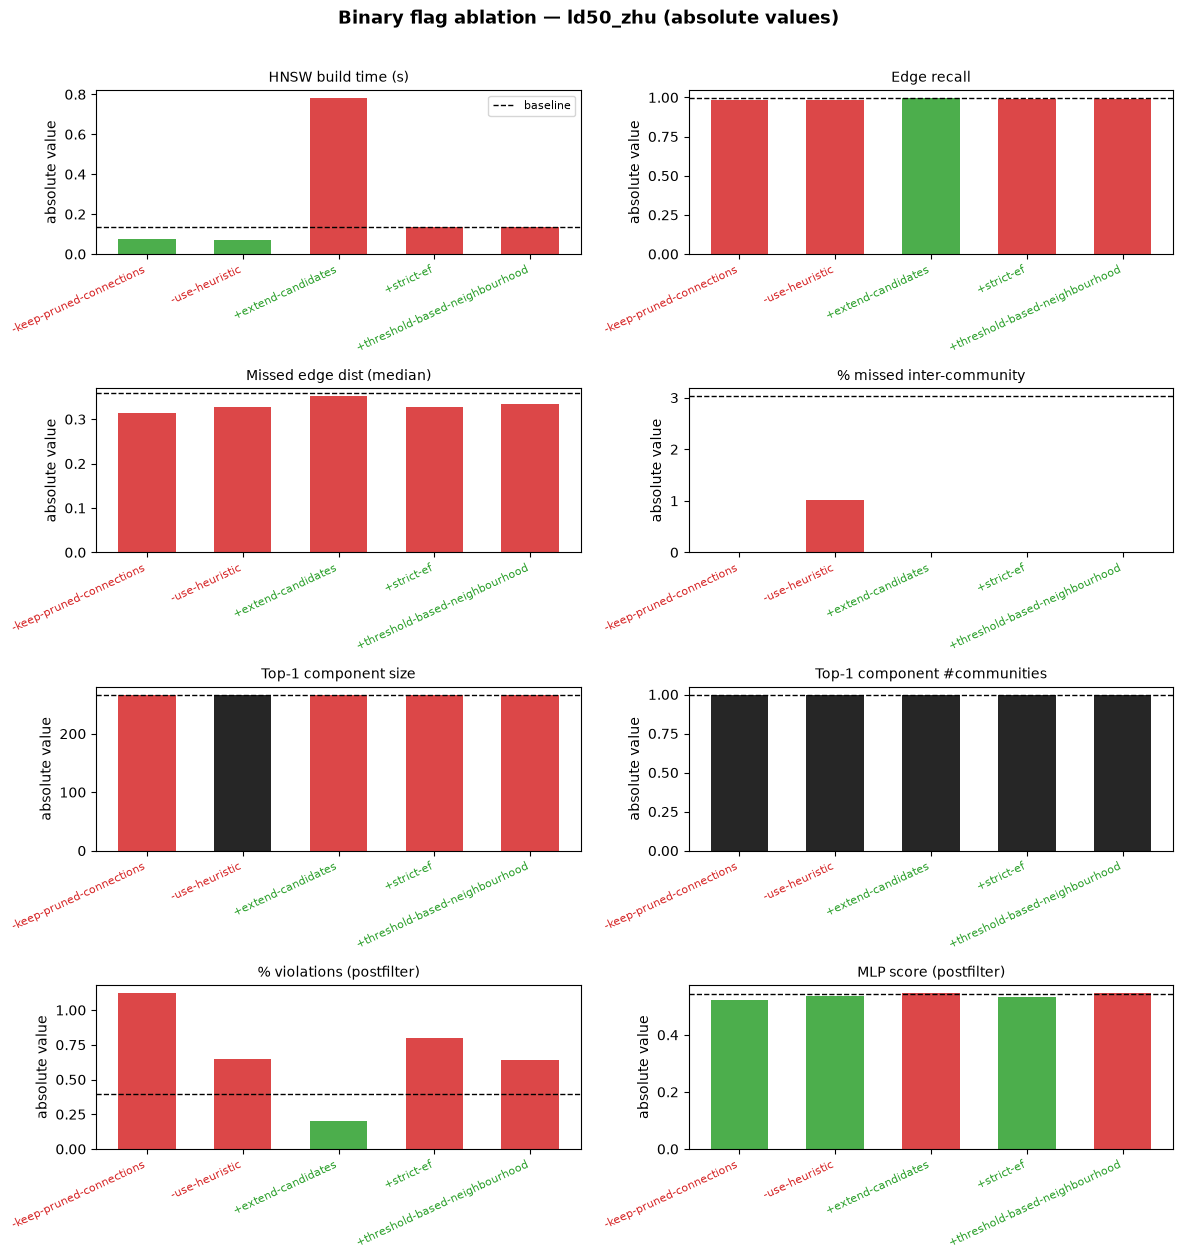

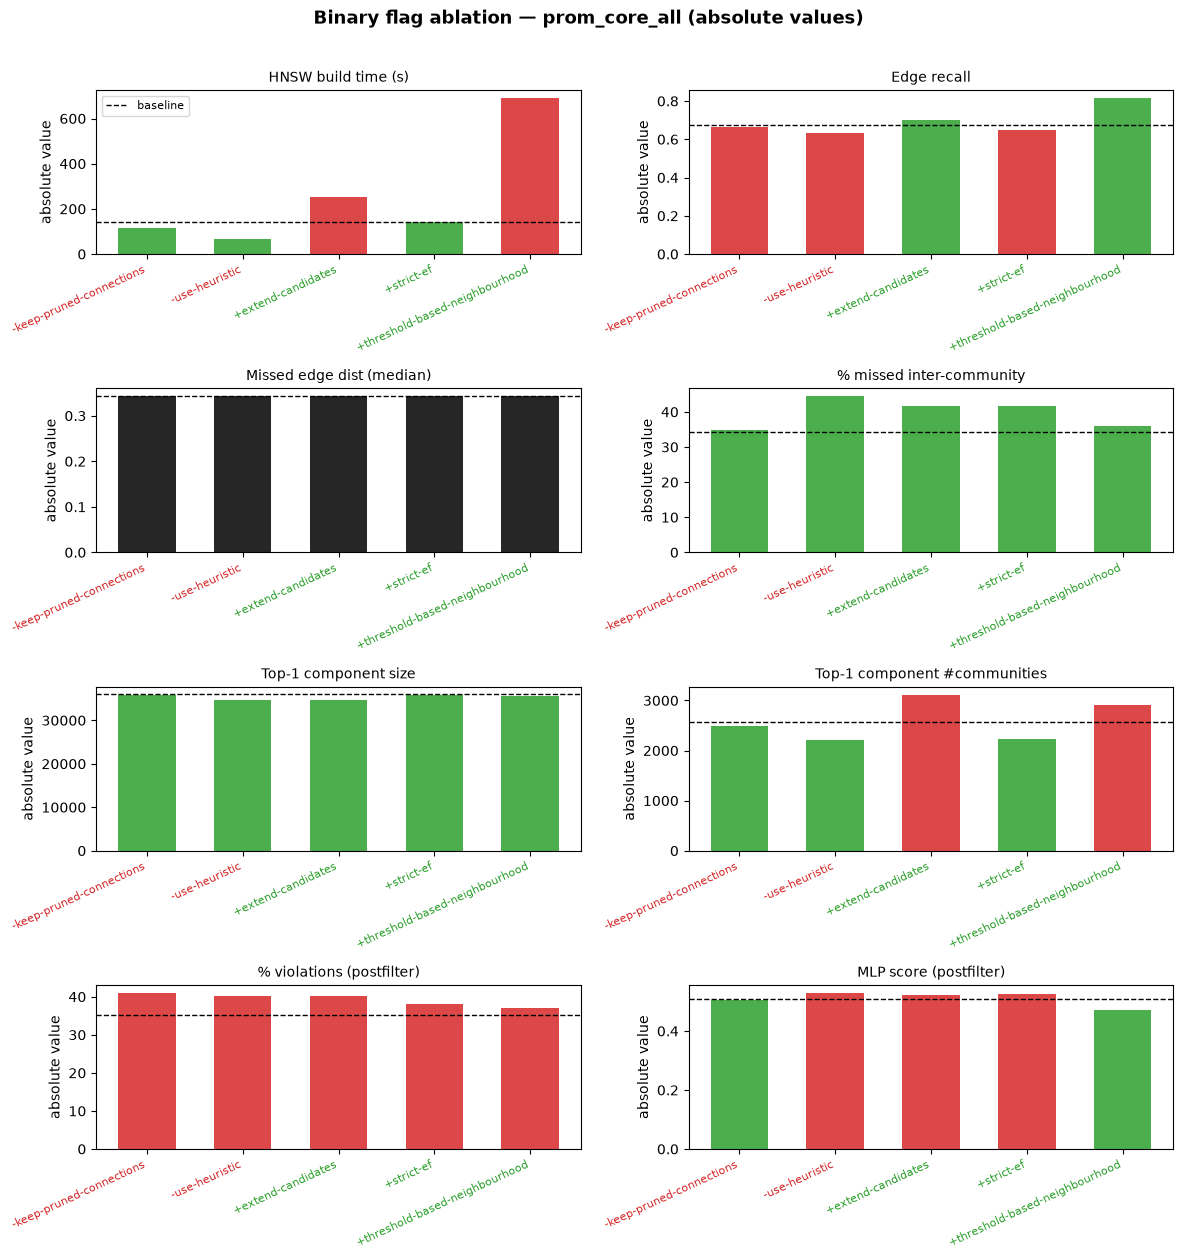

In [12]:

# ── Grouped bar chart (absolute) — one figure per dataset, x = flag variants ──
ncols = 2
nrows = (len(METRICS) + 1) // ncols

for ds_key, ds_color, ds_label in DATASETS:
    baseline = load_flag_baseline(ds_key)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, nrows * 3.2))
    axes = axes.flatten()

    for metric_idx, (title, fn) in enumerate(METRICS):
        ax = axes[metric_idx]
        higher_is_better = METRIC_HIGHER_IS_BETTER[metric_idx]

        abs_vals, bar_colors = [], []
        # baseline bar first
        v0, _ = fn(baseline) if baseline else (0.0, None)

        for label, turned_on, overrides in FLAG_VARIANTS:
            run = load_flag_variant(ds_key, overrides)
            v = fn(run)[0] if run else 0.0
            abs_vals.append(v)
            d = (v - v0) / abs(v0) * 100 if v0 != 0 else 0.0
            bar_colors.append(delta_color(d, higher_is_better))

        ax.bar(x, abs_vals, color=bar_colors, alpha=0.85, width=0.6)
        ax.axhline(v0, color="black", linewidth=1.0, linestyle="--", label="baseline")
        ax.set_title(title, fontsize=10)
        ax.set_ylabel("absolute value")
        ax.set_xticks(x)
        ax.set_xticklabels(xtick_labels, fontsize=8, rotation=25, ha="right")
        for tick, color in zip(ax.get_xticklabels(), xtick_colors):
            tick.set_color(color)

    for ax in axes[len(METRICS):]:
        ax.set_visible(False)

    axes[0].legend(fontsize=8)
    fig.suptitle(f"Binary flag ablation — {ds_label} (absolute values)", fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# Runtime scaling — refnd vs hestia

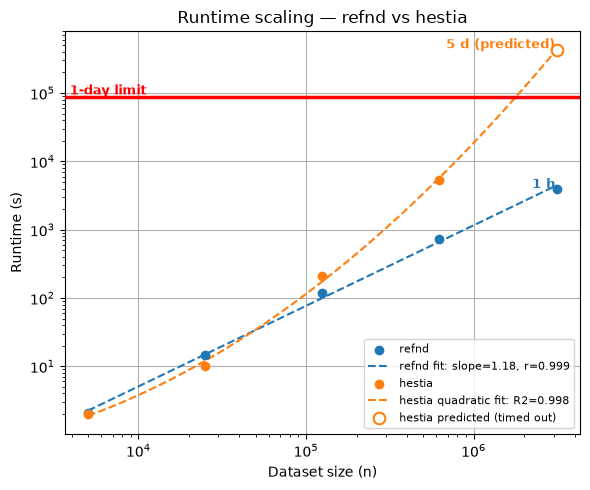

In [28]:
runtime_data = json.loads(Path("results/runtime_atlas.json").read_text())

fig, ax = plt.subplots(figsize=(6, 5))

METHOD_COLORS = {"refnd": "#1f77b4", "hestia": "#ff7f0e"}
ONE_DAY_S = 86400

for method, color in METHOD_COLORS.items():
    rows = [r for r in runtime_data if r["method"] == method and r["status"] == "ok"]
    rows.sort(key=lambda r: r["size"])
    sizes = np.array([r["size"] for r in rows], dtype=float)
    runtimes = np.array([r["runtime_s"] for r in rows], dtype=float)
    timeout_rows = [r for r in runtime_data if r["method"] == method and r["status"] == "timeout"]

    ax.scatter(sizes, runtimes, color=color, label=method, zorder=3)

    log_sizes, log_runtimes = np.log10(sizes), np.log10(runtimes)

    if timeout_rows and len(sizes) >= 3:
        # hestia's growth accelerates (local slope 1.0 -> 1.9 -> 2.0 across successive
        # size steps), so a single power law (straight line in log-log) underestimates
        # near the timeout. Fit one continuous quadratic curve in log-log space across
        # the whole range instead of splicing a straight fit with a separate
        # extrapolation segment (which produced a kink at the last point).
        coeffs = np.polyfit(log_sizes, log_runtimes, 2)
        pred_log = np.polyval(coeffs, log_sizes)
        ss_res = np.sum((log_runtimes - pred_log) ** 2)
        ss_tot = np.sum((log_runtimes - log_runtimes.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot

        fit_max_log = max([log_sizes.max()] + [np.log10(r["size"]) for r in timeout_rows])
        fit_log_sizes = np.linspace(log_sizes.min(), fit_max_log, 200)
        fit_runtimes = 10 ** np.polyval(coeffs, fit_log_sizes)
        ax.plot(10 ** fit_log_sizes, fit_runtimes, color=color, linestyle="--",
                label=f"{method} quadratic fit: R2={r2:.3f}")

        largest_size = max(r["size"] for r in timeout_rows)
        largest_runtime = 10 ** np.polyval(coeffs, np.log10(largest_size))
        label_text = f"{largest_runtime / 86400:.0f} d (predicted)"

        for r in timeout_rows:
            pred_runtime = 10 ** np.polyval(coeffs, np.log10(r["size"]))
            ax.scatter([r["size"]], [pred_runtime], facecolors="white", edgecolors=color,
                       linewidths=1.5, marker="o", s=70, zorder=4,
                       label=f"{method} predicted (timed out)")
    else:
        slope, intercept, r_val, _, _ = stats.linregress(log_sizes, log_runtimes)
        fit_sizes = np.logspace(log_sizes.min(), log_sizes.max(), 100)
        fit_runtimes = 10 ** (slope * np.log10(fit_sizes) + intercept)
        ax.plot(fit_sizes, fit_runtimes, color=color, linestyle="--",
                label=f"{method} fit: slope={slope:.2f}, r={r_val:.3f}")

        largest_size = sizes[-1]
        largest_runtime = runtimes[-1]
        label_text = f"{largest_runtime / 3600:.0f} h"

    ax.annotate(label_text, (largest_size, largest_runtime),
                textcoords="offset points", xytext=(-1, 1), fontsize=9,
                color=color, fontweight="bold", ha="right")

ax.set_xscale("log")
ax.set_yscale("log")

ax.axhline(ONE_DAY_S, color="red", linewidth=2.5, zorder=5)
ax.text(0.01, ONE_DAY_S, "1-day limit", color="red", fontsize=9, fontweight="bold",
        va="bottom", ha="left", transform=ax.get_yaxis_transform())

ax.set_xlabel("Dataset size (n)")
ax.set_ylabel("Runtime (s)")
ax.set_title("Runtime scaling — refnd vs hestia")
ax.legend(fontsize=8)
plt.tight_layout()
plt.grid()
plt.show()


# Memory scaling — refnd vs hestia

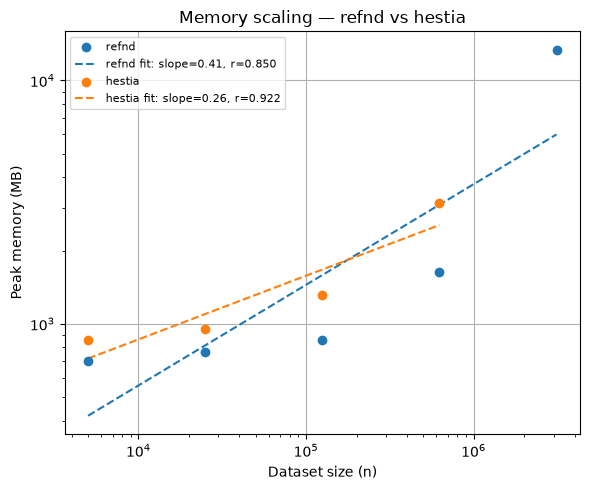

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

for method, color in METHOD_COLORS.items():
    rows = [r for r in runtime_data if r["method"] == method and r["status"] == "ok"
            and r["peak_mem_mb"] is not None]
    rows.sort(key=lambda r: r["size"])
    sizes = np.array([r["size"] for r in rows], dtype=float)
    mem   = np.array([r["peak_mem_mb"] for r in rows], dtype=float)

    ax.scatter(sizes, mem, color=color, label=method, zorder=3)

    log_sizes, log_mem = np.log10(sizes), np.log10(mem)
    slope, intercept, r_val, _, _ = stats.linregress(log_sizes, log_mem)
    fit_sizes = np.logspace(log_sizes.min(), log_sizes.max(), 100)
    fit_mem   = 10 ** (slope * np.log10(fit_sizes) + intercept)
    ax.plot(fit_sizes, fit_mem, color=color, linestyle="--",
            label=f"{method} fit: slope={slope:.2f}, r={r_val:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Dataset size (n)")
ax.set_ylabel("Peak memory (MB)")
ax.set_title("Memory scaling — refnd vs hestia")
ax.legend(fontsize=8)
plt.tight_layout()
plt.grid()
plt.show()


# Edges vs nodes scaling — refnd

In [15]:
detailed = json.loads(Path("results/scaling_detailed_refnd.json").read_text())
detailed = [r for r in detailed if "n_edges" in r]
detailed.sort(key=lambda r: r["size"])

sizes = np.array([r["size"]    for r in detailed], dtype=float)
edges = np.array([r["n_edges"] for r in detailed], dtype=float)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(sizes, sizes, color="#1f77b4", marker="o", label="nodes", zorder=3)
ax.scatter(sizes, edges, color="#ff7f0e", marker="s", label="edges", zorder=3)

for arr, color, lbl in [(sizes, "#1f77b4", "nodes"), (edges, "#ff7f0e", "edges")]:
    log_s, log_v = np.log10(sizes), np.log10(arr)
    slope, intercept, r_val, _, _ = stats.linregress(log_s, log_v)
    fit_x = np.logspace(log_s.min(), log_s.max(), 100)
    fit_y = 10 ** (slope * np.log10(fit_x) + intercept)
    ax.plot(fit_x, fit_y, color=color, linestyle="--",
            label=f"{lbl} fit: slope={slope:.2f}, r={r_val:.3f}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Count")
ax.set_title("Nodes vs HNSW edges scaling — refnd")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'results/scaling_detailed_refnd.json'

# Post-filter effect — % violations and MLP score

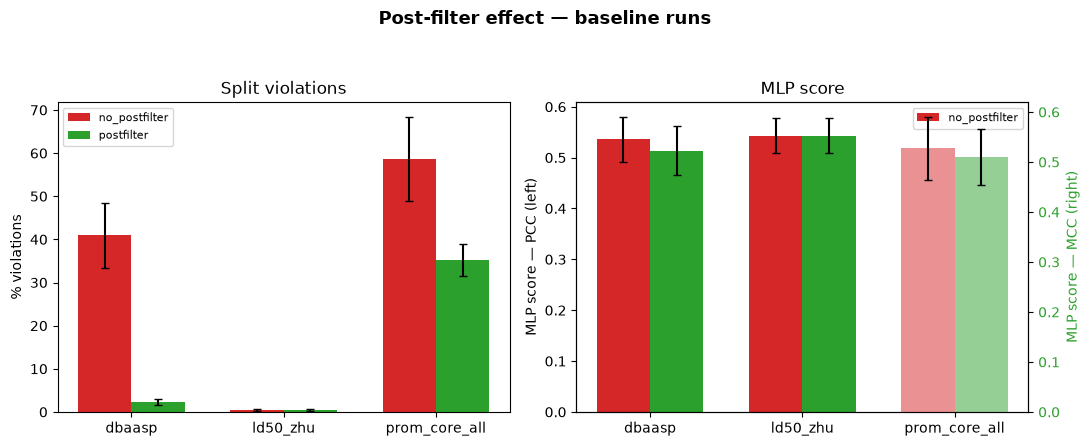

In [16]:
SPLIT_VARIANTS = ["no_postfilter", "postfilter"]
VARIANT_COLORS = {"no_postfilter": "#d62728", "postfilter": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax_viol = axes[0]
ax_score = axes[1]
ax_score2 = ax_score.twinx()
ax_score2.set_ylabel("MLP score — MCC (right)", color="#2ca02c")
ax_score2.tick_params(axis="y", labelcolor="#2ca02c")

# Separate datasets by metric type for x-tick positioning
pcc_ds = [(i, ds) for i, ds in enumerate(DATASETS) if DATASET_METRIC[ds[0]] == "PCC"]
mcc_ds = [(i, ds) for i, ds in enumerate(DATASETS) if DATASET_METRIC[ds[0]] == "MCC"]
x = np.arange(len(DATASETS))
width = 0.35

for i, variant in enumerate(SPLIT_VARIANTS):
    violations, violations_std = [], []
    pcc_scores, pcc_scores_std = [], []
    mcc_scores_list, mcc_scores_std_list = [], []
    pcc_x, mcc_x = [], []

    for j, (ds_key, _, _) in enumerate(DATASETS):
        baseline = load_flag_baseline(ds_key)
        split = _get(baseline, "results", "edges", "split", variant)
        violations.append(split["p_violations_mean[%]"])
        violations_std.append(split["p_violations_std[%]"])
        if DATASET_METRIC[ds_key] == "PCC":
            pcc_scores.append(split["mlp_score_mean"])
            pcc_scores_std.append(split["mlp_score_std"])
            pcc_x.append(j)
        else:
            mcc_scores_list.append(split["mlp_score_mean"])
            mcc_scores_std_list.append(split["mlp_score_std"])
            mcc_x.append(j)

    offset = (i - 0.5) * width
    ax_viol.bar(x + offset, violations, width, yerr=violations_std, capsize=3,
                color=VARIANT_COLORS[variant], label=variant)
    if pcc_x:
        ax_score.bar(np.array(pcc_x) + offset, pcc_scores, width, yerr=pcc_scores_std, capsize=3,
                     color=VARIANT_COLORS[variant], label=variant if i == 0 else "")
    if mcc_x:
        ax_score2.bar(np.array(mcc_x) + offset, mcc_scores_list, width, yerr=mcc_scores_std_list,
                      capsize=3, color=VARIANT_COLORS[variant], alpha=0.5)

ax_viol.set_xticks(x)
ax_viol.set_xticklabels([label for _, _, label in DATASETS])
ax_viol.set_ylabel("% violations")
ax_viol.set_title("Split violations")
ax_viol.legend(fontsize=8)

ax_score.set_xticks(x)
ax_score.set_xticklabels([label for _, _, label in DATASETS])
ax_score.set_ylabel("MLP score — PCC (left)")
ax_score.set_title("MLP score")
ax_score.legend(fontsize=8)

fig.suptitle("Post-filter effect — baseline runs", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
